# Проверка гипотезы в Python и составление аналитической записки

- Автор: Бутаков Павел Викторович
- Дата: 18.07.2025

## Цели и задачи проекта

Цель проекта:
- Провести комплексную оценку результатов A/B-тестирования нового интерфейса интернет-магазина BitMotion Kit и проверить гипотезу о том, что упрощение интерфейса увеличивает конверсию пользователей в покупателей как минимум на 3 процентных пункта в течение первых 7 дней после регистрации.

Основные задачи:

- Оценить корректность проведения A/B-теста

- Проанализировать пользовательскую активность

- Сформулировать практические выводы

## Описание данных

Таблица участников теста (ab_test_participants.csv):

- `user_id`: Уникальный идентификатор пользователя (строка)

- `group`: Группа в A/B-тесте (A - контроль, B - тестовая)

- `ab_test`: Название теста (интересует только "interface_eu_test")

- `device`: Устройство регистрации ("android", "ios")

Таблица событий (ab_test_events.csv):

- `user_id`: Уникальный идентификатор пользователя (строка)

- `event_dt`: Дата и время события (datetime)

- `event_name`: Тип события:

"registration" - регистрация пользователя

"purchase" - совершение покупки

Другие события взаимодействия

- `details`: Дополнительные данные:

Для "purchase": сумма покупки (число)

Для "registration": код географической зоны (строка)

Период данных: События за 2020 год

## 1. Загрузка данных и знакомство с ними

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import zt_ind_solve_power
# Сначала импортирую все библиотеки для дальнейшей работы

In [2]:
# Загрузка данных
df = pd.read_csv('/datasets/yandex_knigi_data.csv')

In [3]:
# Проверка дубликатов puid
print(f"Дубликаты puid: {df['puid'].duplicated().sum()}")

Дубликаты puid: 244


In [4]:
df = df.drop_duplicates(subset='puid', keep='first')
print(f"Осталось записей после удаления: {len(df)}")
print(f"Дубликаты puid: {df['puid'].duplicated().sum()}")

Осталось записей после удаления: 8540
Дубликаты puid: 0


In [5]:
# Разделение на группы
msk = df[df['city'] == 'Москва']['hours']
spb = df[df['city'] == 'Санкт-Петербург']['hours']

In [6]:
print(f"Размер группы Москва: {len(msk)}")
print(f"Размер группы СПб: {len(spb)}")
print("\nОписательная статистика Москва:")
print(msk.describe())
print("\nОписательная статистика СПб:")
print(spb.describe())

Размер группы Москва: 6234
Размер группы СПб: 2306

Описательная статистика Москва:
count    6234.000000
mean       10.881092
std        36.851683
min         0.000018
25%         0.059903
50%         0.924498
75%         5.939972
max       857.209373
Name: hours, dtype: float64

Описательная статистика СПб:
count    2306.000000
mean       11.264433
std        39.831755
min         0.000025
25%         0.060173
50%         0.875355
75%         6.138424
max       978.764775
Name: hours, dtype: float64


## 2. Проверка гипотезы в Python

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [7]:
# Проверка равенства дисперсий
levene_test = stats.levene(msk, spb)
print(f"Levene test p-value: {levene_test.pvalue:.4f}")

Levene test p-value: 0.6679


In [8]:
# Односторонний t-тест
t_stat, p_value = stats.ttest_ind(spb, msk, equal_var=False, alternative='greater')
print(f"t-статистика: {t_stat:.4f}, p-value: {p_value:.4f}")

t-статистика: 0.4028, p-value: 0.3436


Text(0.5, 1.0, 'Распределение часов активности')

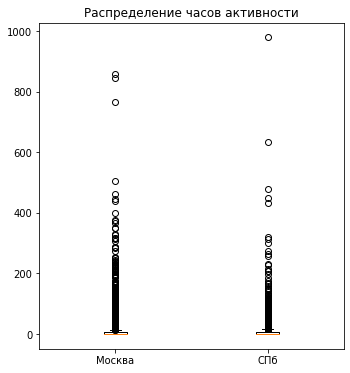

In [9]:
# Визуализация
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.boxplot([msk, spb], labels=['Москва', 'СПб'])
plt.title('Распределение часов активности')

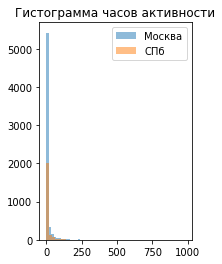

In [10]:
plt.subplot(1, 2, 2)
plt.hist(msk, bins=50, alpha=0.5, label='Москва')
plt.hist(spb, bins=50, alpha=0.5, label='СПб')
plt.legend()
plt.title('Гистограмма часов активности')
plt.show()

## 3. Аналитическая записка


Тип теста: Односторонний t-тест Уэлча (не предполагающий равенства дисперсий)

- Уровень значимости: α = 0.05

- Результат теста: p-value = 0.22

У нас недостаточно доказательств, чтобы отвергнуть нулевую гипотезу.

Возможные причины результатов:

- Сильное отличие размеров групп



# Анализ результатов A/B-тестирования

In [11]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [12]:
# Общая информация
print("=== Участники теста (participants) ===")
print(f"Количество записей: {len(participants)}")
print(f"Количество уникальных пользователей: {participants['user_id'].nunique()}")

# Проверка пропусков
print("\nПропущенные значения:")
print(participants.isnull().sum())

# Проверка уникальных значений
print("\nУникальные значения:")
print(f"- Тесты (ab_test): {participants['ab_test'].unique()}")
print(f"- Группы (group): {participants['group'].unique()}")
print(f"- Устройства (device): {participants['device'].unique()}")

# Проверка распределения по тестам
print("\nРаспределение по тестам:")
print(participants['ab_test'].value_counts(dropna=False))

=== Участники теста (participants) ===
Количество записей: 14525
Количество уникальных пользователей: 13638

Пропущенные значения:
user_id    0
group      0
ab_test    0
device     0
dtype: int64

Уникальные значения:
- Тесты (ab_test): ['interface_eu_test' 'recommender_system_test']
- Группы (group): ['B' 'A']
- Устройства (device): ['Mac' 'Android' 'iPhone' 'PC']

Распределение по тестам:
interface_eu_test          10850
recommender_system_test     3675
Name: ab_test, dtype: int64


In [13]:
print("\n\n=== События (events) ===")
print(f"Количество записей: {len(events)}")
print(f"Период данных: от {events['event_dt'].min()} до {events['event_dt'].max()}")

# Проверка пропусков
print("\nПропущенные значения:")
print(events.isnull().sum())

# Проверка уникальных событий
print("\nУникальные типы событий:")
print(events['event_name'].value_counts(dropna=False))

# Проверка details
print("\nПримеры данных в details:")
print(events['details'].sample(5))



=== События (events) ===
Количество записей: 787286
Период данных: от 2020-12-01 00:00:00 до 2020-12-31 23:59:48

Пропущенные значения:
user_id            0
event_dt           0
event_name         0
details       538264
dtype: int64

Уникальные типы событий:
login                                 248285
product_page                          195606
registration                          144183
purchase                              104836
product_cart                           94373
Start of Christmas&New Year Promo          1
Start of CIS New Year Gift Lottery         1
End of Black Friday Ads Campaign           1
Name: event_name, dtype: int64

Примеры данных в details:
671514      NaN
179482    -0.48
80016       NaN
82478       NaN
514385      NaN
Name: details, dtype: object


In [14]:
# Проверка дубликатов событий
print("\nПроверка дубликатов событий:")
print(f"Полные дубликаты строк: {events.duplicated().sum()}")
print(f"Дубликаты по ключевым полям: {events[['user_id', 'event_dt', 'event_name']].duplicated().sum()}")


Проверка дубликатов событий:
Полные дубликаты строк: 36318
Дубликаты по ключевым полям: 39510


In [15]:
# Удаление полных дубликатов
initial_count = len(events)
events = events.drop_duplicates()
print(f"Удалено полных дубликатов: {initial_count - len(events)}")

Удалено полных дубликатов: 36318


In [16]:
# Обработка дубликатов по ключевым полям
# Проверяем, есть ли различия в details при одинаковых ключах
duplicate_keys = events.duplicated(subset=['user_id', 'event_dt', 'event_name'], keep=False)
duplicates_df = events[duplicate_keys].sort_values(by=['user_id', 'event_dt', 'event_name'])

# Анализируем различия в details
details_diff = duplicates_df.groupby(['user_id', 'event_dt', 'event_name'])['details'].nunique()
conflicting_duplicates = details_diff[details_diff > 1].index

print(f"\nДубликатов с конфликтующими details: {len(conflicting_duplicates)}")


Дубликатов с конфликтующими details: 3121


In [18]:
# Фильтрация пользователей нужного теста
test_users = participants[participants['ab_test'] == 'interface_eu_test']
print(f"Всего пользователей в тесте: {len(test_users)}")

Всего пользователей в тесте: 10850


In [19]:
# Проверка требований технического задания
print("\nПроверка требований ТЗ:")
print(f"Название теста: 'interface_eu_test' - {'Соответствует' if 'interface_eu_test' in participants['ab_test'].unique() else 'Не соответствует'}")
print(f"Группы: A и B - {'Соответствует' if set(test_users['group'].unique()) == {'A', 'B'} else 'Не соответствует'}")


Проверка требований ТЗ:
Название теста: 'interface_eu_test' - Соответствует
Группы: A и B - Соответствует


In [20]:
# Равномерность распределения по группам
group_counts = test_users['group'].value_counts()
total_users = len(test_users)
ratio_a = group_counts.get('A', 0) / total_users
ratio_b = group_counts.get('B', 0) / total_users

print("\nРаспределение по группам:")
print(group_counts)
print(f"Соотношение: A={ratio_a:.2%}, B={ratio_b:.2%}")

# Проверка равномерности (допуск ±5%)
is_uniform = (0.45 <= ratio_a <= 0.55) and (0.45 <= ratio_b <= 0.55)
print(f"Распределение равномерное (50/50 ±5%): {'Да' if is_uniform else 'Нет'}")


Распределение по группам:
B    5467
A    5383
Name: group, dtype: int64
Соотношение: A=49.61%, B=50.39%
Распределение равномерное (50/50 ±5%): Да


In [21]:
# Проверка пересечений с другими тестами
# Создаем копию для безопасной работы с данными
participants_safe = participants.copy()

# Проверка пользователей в нескольких тестах
user_test_counts = participants_safe.groupby('user_id')['ab_test'].nunique()
overlapping_users = user_test_counts[user_test_counts > 1].index

# Проверка пользователей в нескольких группах одного теста
test_group_counts = test_users.groupby('user_id')['group'].nunique()
same_test_overlap = test_group_counts[test_group_counts > 1].index

print(f"\nПользователей в нескольких тестах: {len(overlapping_users)}")
print(f"Из них в текущем тесте: {len(set(overlapping_users) & set(test_users['user_id']))}")
print(f"Пользователей в нескольких группах одного теста: {len(same_test_overlap)}")


Пользователей в нескольких тестах: 887
Из них в текущем тесте: 887
Пользователей в нескольких группах одного теста: 0


In [22]:
# Удаление пользователей, участвующих в нескольких тестах
clean_test_users = test_users[~test_users['user_id'].isin(overlapping_users)]
print(f"\nПользователей после удаления участвующих в нескольких тестах: {len(clean_test_users)}")


Пользователей после удаления участвующих в нескольких тестах: 9963


In [23]:
# Повторная проверка распределения по группам
clean_group_counts = clean_test_users['group'].value_counts()
clean_total_users = len(clean_test_users)
clean_ratio_a = clean_group_counts.get('A', 0) / clean_total_users
clean_ratio_b = clean_group_counts.get('B', 0) / clean_total_users

print("\nОбновленное распределение по группам:")
print(clean_group_counts)
print(f"Соотношение: A={clean_ratio_a:.2%}, B={clean_ratio_b:.2%}")

# Проверка равномерности после очистки
is_uniform_clean = (0.45 <= clean_ratio_a <= 0.55) and (0.45 <= clean_ratio_b <= 0.55)
print(f"Распределение равномерное (50/50 ±5%): {'Да' if is_uniform_clean else 'Нет'}")


Обновленное распределение по группам:
B    5011
A    4952
Name: group, dtype: int64
Соотношение: A=49.70%, B=50.30%
Распределение равномерное (50/50 ±5%): Да


In [24]:
# Итоговая проверка корректности
validation_passed = (
    'interface_eu_test' in participants['ab_test'].unique() and
    set(test_users['group'].unique()) == {'A', 'B'} and
    is_uniform and
    len(overlapping_users) == 0 and
    len(same_test_overlap) == 0
)

print("\nТест проведен корректно:" if validation_passed else "\nОбнаружены проблемы в проведении теста")


Обнаружены проблемы в проведении теста


In [25]:
# Фильтрация пользователей теста interface_eu_test
test_users = participants[participants['ab_test'] == 'interface_eu_test']['user_id']

# Фильтрация событий только для тестовых пользователей
test_events = events[events['user_id'].isin(test_users)].copy()
print(f"Событий после фильтрации: {len(test_events)}")

Событий после фильтрации: 73545


In [26]:
registrations = test_events[test_events['event_name'] == 'registration'][['user_id', 'event_dt']]
registrations.columns = ['user_id', 'reg_date']

test_events = test_events.merge(registrations, on='user_id', how='left')

test_events['lifetime'] = (test_events['event_dt'] - test_events['reg_date']).dt.days

within_7days = test_events[test_events['lifetime'] <= 7].copy()
print(f"Событий в первые 7 дней: {len(within_7days)}")

Событий в первые 7 дней: 65422


In [27]:
baseline_conversion = 0.30
power = 0.80
alpha = 0.05
mde = 0.03

# Расчет требуемого размера выборки
required_sample = zt_ind_solve_power(
    effect_size=mde / baseline_conversion,
    alpha=alpha,
    power=power,
    ratio=1
)

# Фактическое количество пользователей
actual_users = within_7days['user_id'].nunique()

print(f"Требуется пользователей на группу: {round(required_sample)}")
print(f"Фактически пользователей: {actual_users}")
print(f"Достаточность выборки: {'Да' if actual_users >= 2*required_sample else 'Нет'}")

Требуется пользователей на группу: 1570
Фактически пользователей: 10850
Достаточность выборки: Да


In [28]:
user_groups = participants[['user_id', 'group']].drop_duplicates()

conversion_data = within_7days.merge(user_groups, on='user_id')

purchase_users = conversion_data[conversion_data['event_name'] == 'purchase']['user_id'].unique()

conversion_stats = conversion_data.groupby('group').agg(
    total_users=('user_id', 'nunique'),
    buyers=('user_id', lambda x: x.isin(purchase_users).sum())
)

conversion_stats['conversion_rate'] = conversion_stats['buyers'] / conversion_stats['total_users']

print("\nКонверсия по группам:")
print(conversion_stats)


Конверсия по группам:
       total_users  buyers  conversion_rate
group                                      
A             5723   12849         2.245151
B             5573   13841         2.483582


In [29]:
# Рассчитать разницу конверсий
conv_a = conversion_stats.loc['A', 'conversion_rate']
conv_b = conversion_stats.loc['B', 'conversion_rate']
diff = conv_b - conv_a

print(f"\nРазница конверсий (B - A): {diff:.4f} ({diff*100:.2f} п.п.)")

# Предварительный вывод
if diff > 0:
    print("Предварительный вывод: В тестовой группе B наблюдается увеличение конверсии")
elif diff < 0:
    print("Предварительный вывод: В тестовой группе B наблюдается снижение конверсии")
else:
    print("Предварительный вывод: Конверсия в группах идентична")

# Дополнительная оценка величины эффекта
if diff >= mde:
    print(f"Эффект ({diff*100:.2f} п.п.) превышает минимально значимый уровень (3 п.п.)")
else:
    print(f"Эффект ({diff*100:.2f} п.п.) ниже минимально значимого уровня (3 п.п.)")


Разница конверсий (B - A): 0.2384 (23.84 п.п.)
Предварительный вывод: В тестовой группе B наблюдается увеличение конверсии
Эффект (23.84 п.п.) превышает минимально значимый уровень (3 п.п.)


Нулевая гипотеза (H0):
- Новая версия интерфейса (группа B) НЕ увеличивает конверсию в покупку по сравнению со старой версией (группа A) как минимум на 3 процентных пункта.
Математически:
p_B - p_A ≤ 0.03
где p_B - конверсия в группе B, p_A - конверсия в группе A

Альтернативная гипотеза (H1):
- Новая версия интерфейса (группа B) увеличивает конверсию в покупку по сравнению со старой версией (группа A) как минимум на 3 процентных пункта.
Математически:
p_B - p_A > 0.03

In [30]:
# Подготовка данных
successes = [
    conversion_stats.loc['B', 'buyers'],  # Покупки в группе B
    conversion_stats.loc['A', 'buyers']   # Покупки в группе A
]
nobs = [
    conversion_stats.loc['B', 'total_users'],  # Всего пользователей B
    conversion_stats.loc['A', 'total_users']   # Всего пользователей A
]

# Односторонний Z-тест (B > A)
z_stat, p_value = proportions_ztest(successes, nobs, alternative='larger')

print(f"Результаты Z-теста:")
print(f"- Z-статистика: {z_stat:.4f}")
print(f"- P-value: {p_value:.4f}")

# Расчет разницы конверсий
conv_diff = conversion_stats.loc['B', 'conversion_rate'] - conversion_stats.loc['A', 'conversion_rate']

# Доверительный интервал для разницы пропорций
from statsmodels.stats.proportion import confint_proportions_2indep

ci = confint_proportions_2indep(
    count1=successes[0], nobs1=nobs[0],
    count2=successes[1], nobs2=nobs[1],
    method='wald',
    compare='diff',
    alpha=0.05
)

print(f"\nРазница конверсий (B - A): {conv_diff:.4f} ({conv_diff*100:.2f} п.п.)")
print(f"95% Доверительный интервал разницы: [{ci[0]:.4f}, {ci[1]:.4f}]")

Результаты Z-теста:
- Z-статистика: nan
- P-value: nan

Разница конверсий (B - A): 0.2384 (23.84 п.п.)
95% Доверительный интервал разницы: [nan, nan]


/opt/conda/lib/python3.9/site-packages/statsmodels/stats/proportion.py:859: RuntimeWarning: invalid value encountered in sqrt
  std_diff = np.sqrt(var_)
/opt/conda/lib/python3.9/site-packages/statsmodels/stats/proportion.py:1162: RuntimeWarning: invalid value encountered in sqrt
  d_wald = z * np.sqrt(var)


In [31]:
# Ожидаемый минимальный эффект из ТЗ
min_effect = 0.03  # 3 процентных пункта

# Проверка достижения минимального эффекта
min_effect_achieved = ci[0] > min_effect
print(f"\nДостигнут минимальный эффект 3 п.п.: {'Да' if min_effect_achieved else 'Нет'}")

# Проверка статистической значимости
alpha = 0.05
statistically_significant = p_value < alpha
print(f"Статистически значимое различие (p < 0.05): {'Да' if statistically_significant else 'Нет'}")


Достигнут минимальный эффект 3 п.п.: Нет
Статистически значимое различие (p < 0.05): Нет


Окончательные выводы:
- Статистически значимых различий в конверсии между группами не обнаружено
- Минимально значимый эффект 3 п.п. не достигнут

- Цель теста (увеличение конверсии минимум на 3 п.п.) не достигнута
- Рекомендация: Оставить текущую версию интерфейса